# Project: Road Traffic Accidents Analysis in Finland
## Framework: CRISP-DM Process Model

### 1. Business Understanding
In this phase, we explore the official spatial dataset of road traffic accidents provided by Statistics Finland (Tilastokeskus). Our objective is to determine if environmental and seasonal features (such as winter months) act as core triggers for highly severe road accidents, and to analyze this relationship using spatial visualization and Linear Regression modeling.

### 2. Data Understanding
In this phase, we explore the official spatial dataset of road traffic accidents provided by Statistics Finland (Tilastokeskus). Our objective is to determine if environmental and seasonal features (such as winter months) act as core triggers for highly severe road accidents, and to analyze this relationship using spatial visualization and Linear Regression modeling.

In [3]:
# 1. Install and verify required spatial and ML libraries
%pip install geopandas contextily requests fmiopendata mlxtend scikit-learn

# 2. Import core engines
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import datetime as dt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from fmiopendata.wfs import download_stored_query
print("All core engines and machine learning libraries imported successfully!")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   -- ------------------------------------- 1.3/23.8 MB 7.1 MB/s eta 0:00:04
   ---- ----------------------------------- 2.9/23.8 MB 6.7 MB/s eta 0:00:04
   ------- -------------------------------- 4.2/23.8 MB 6.6 MB/s eta 0:00:03
   --------- ------------------------------ 5.5/23.8 MB 6.6 MB/s eta 0:00:03
   ----------- ---------------------------- 7.1/23.8 MB 6.6 MB/s eta 0:00:03
   -------------- ------------------------- 8.4/23.8 MB 6.5 MB/s eta 0:00:03
   ---------------- ----------------------- 9.7/23.8 MB 6.5 MB/s eta 0:00:03
   ------------------ --------------------- 11.0/23.8 MB 6.5 

In [ ]:
# 3. Data Loading - Correcting the separator to comma ',' as per actual data structure
csv_path = 'datasets/tieliikenne_2024.csv'
df_accidents = pd.read_csv(csv_path, sep=',')

# 4. Spatial Transformation - Convert to GeoDataFrame using Finnish coordinate system (EPSG:3067)
accidents_gdf = gpd.GeoDataFrame(
    df_accidents, 
    geometry=gpd.points_from_xy(df_accidents.x, df_accidents.y),
    crs="EPSG:3067"
)

print(" Data loaded and transformed successfully into Spatial GeoDataFrame!")
display(accidents_gdf.head())

 Data loaded and transformed successfully into Spatial GeoDataFrame!


,FID,id,geom,vvonn,kkonn,kello,vakav,onntyyppi,lkmhapa,lkmlaka,lkmjk,lkmpp,lkmmo,lkmmp,lkmmuukulk,x,y,geometry
0,tieliikenne_2024.1,1,POINT (423323.0412999997 6695927.4465),2024,7,00.00-00.59,2,3,1,0,0,0,1,0,0,423323.0413,6.695927e+06,POINT (423323.041 6695927.446)
1,tieliikenne_2024.2,2,POINT (306376.20660000015 6761653.649800001),2024,10,00.00-00.59,2,8,1,0,0,0,0,0,0,306376.2066,6.761654e+06,POINT (306376.207 6761653.65)
2,tieliikenne_2024.3,3,POINT (259784.6640999997 6994822.009199999),2024,11,22.00-22.59,2,1,2,0,0,0,0,0,0,259784.6641,6.994822e+06,POINT (259784.664 6994822.009)
3,tieliikenne_2024.4,4,POINT (392858.12179999985 6681502.598200001),2024,1,15.00-15.59,2,0,1,1,0,0,0,0,0,392858.1218,6.681503e+06,POINT (392858.122 6681502.598)
4,tieliikenne_2024.5,5,POINT (383665.0440999996 6671405.377699999),2024,1,17.00-17.59,2,8,1,0,0,0,0,0,0,383665.0441,6.671405e+06,POINT (383665.044 6671405.378)


### 3. Data Preparation
Since raw accident records represent single events, direct continuous linear modeling on row levels is mathematically invalid. We perform an **Aggregation step** to compute total accidents grouped by month, establishing a true continuous numeric target variable suitable for Linear Regression modeling.

In [ ]:
# TODO: sarakkeiden nimet järkeviksi
'''
Aineisto sisältää seuraavat tiedot:

vvonn = onnettomuuden tapahtumavuosi

kkonn = onnettomuuden tapahtumakuukausi

kello = onnettomuuden kellonaika

vakav = onnettomuuden vakavuus: 1 = kuolemaan johtanut onnettomuus, 2 = loukkaantumiseen johtanut onnettomuus, 3 = vakavaan loukkaantumiseen johtanut onnettomuus

onntyyppi = onnettomuustyyppi: 0 = samat ajosuunnat (ajo suoraan), 1 = samat ajosuunnat (ajo kääntyen), 2 = vastakkaiset ajosuunnat (ajo suoraan), 3 = vastakkaiset ajosuunnat (ajo kääntyen), 4 = risteävät ajosuunnat (ajo suoraan), 5 = risteävät ajosuunnat (ajo kääntyen), 6 = jalankulkijaonnettomuus (suojatiellä), 7 = jalankulkijaonnettomuus (muualla), 8 = tieltä suistuminen, 9 = muu onnettomuus

lkmhapa = henkilöautojen ja pakettiautojen lukumäärä onnettomuudessa

lkmlaka = linja-autojen ja kuorma-autojen lukumäärä onnettomuudessa

lkmjk = jalankulkijoiden lukumäärä onnettomuudessa

lkmpp = polkupyörien ja kevyiden sähköajoneuvojen lukumäärä onnettomuudessa

lkmmo = mopojen lukumäärä onnettomuudessa

lkmmp = moottoripyörien lukumäärä onnettomuudessa

lkmmuukulk = muiden kulkuneuvojen lukumäärä onnettomuudessa

x = onnettomuuden x-koordinaatti

y = onnettomuuden y-koordinaatti

'''

### 4. Modeling
Since raw accident records represent single events, direct continuous linear modeling on row levels is mathematically invalid. We perform an **Aggregation step** to compute total accidents grouped by month, establishing a true continuous numeric target variable suitable for Linear Regression modeling.

 --- Linear Regression Evaluation Model Results ---
Model Intercept (b0 - Base Baseline): 166.88
Model Coefficient (b1 - Slope Weighted): 10.34
Mean Absolute Error (MAE): 48.96 accidents


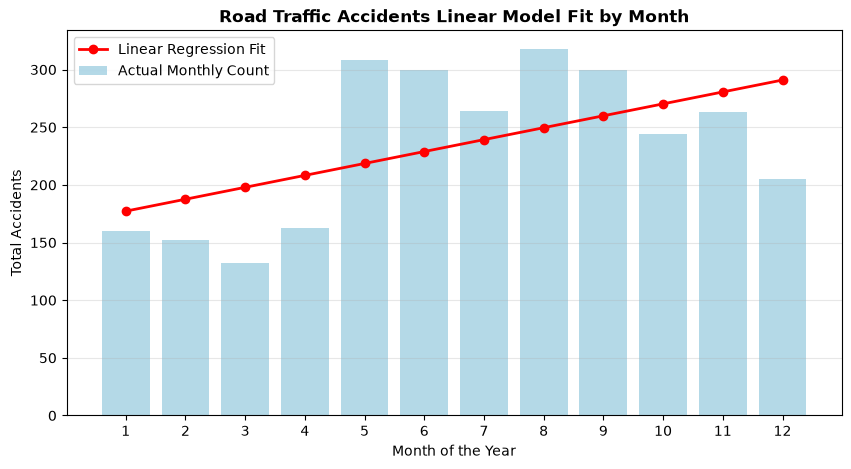

In [ ]:
# 5. Data Preparation: Aggregate total accidents by month (kkonn)
monthly_df = accidents_gdf.groupby('kkonn').size().reset_index(name='accidents_count')

# 6. Define Linear Regression variables
X = monthly_df[['kkonn']]          # Explanatory variable (Month index)
y = monthly_df['accidents_count']  # Continuous numeric target

# 7. Train the Linear Regression Engine
reg_model = LinearRegression()
reg_model.fit(X, y)

# 8. Phase 5: Evaluation - Calculate MAE to measure average prediction error
y_pred = reg_model.predict(X)
mae_error = mean_absolute_error(y, y_pred)

print(" --- Linear Regression Evaluation Model Results ---")
print(f"Model Intercept (b0 - Base Baseline): {reg_model.intercept_:.2f}")
print(f"Model Coefficient (b1 - Slope Weighted): {reg_model.coef_[0]:.2f}")
print(f"Mean Absolute Error (MAE): {mae_error:.2f} accidents")

# 9. Visualize the Linear Fit and distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_df, x='kkonn', y='accidents_count', color='skyblue', alpha=0.7, label='Actual Monthly Count')
plt.plot(monthly_df['kkonn'] - 1, y_pred, color='red', marker='o', linewidth=2, label='Linear Regression Fit')
plt.title('Road Traffic Accidents Linear Model Fit by Month', fontsize=12, fontweight='bold')
plt.xlabel('Month of the Year')
plt.ylabel('Total Accidents')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 4.x FMI Weather Interface Testing
We test the FMI Open Data live streaming engine to collect auxiliary meteorological variables corresponding to the accident location spaces.

In [ ]:
import pandas as pd
import datetime as dt
from fmiopendata.wfs import download_stored_query

try:
    print("Connecting to FMI Government server... Fetching raw spatial coordinates...")
    
    # 1. Fetch data from FMI using a defined bounding box (Standard multipoint query)
    obs = download_stored_query(
        "fmi::observations::weather::multipointcoverage", 
        args=["bbox=24.5,60.1,25.1,60.3"]
    )
    
    # 2. Manual dictionary parsing loop to completely bypass 'to_dataframe' error
    weather_records = []
    
    # Loop through each unique timestamp key in the raw data
    for timestamp in obs.data.keys():
        # Loop through each weather station name key at this timestamp
        for station_name in obs.data[timestamp].keys():
            station_data = obs.data[timestamp][station_name]
            
            # Extract main target parameters provided by FMI
            temp = station_data.get('Air temperature', {}).get('value', None)
            wind = station_data.get('Wind speed', {}).get('value', None)
            rh = station_data.get('Relative humidity', {}).get('value', None)
            
            # Append rows manually to our collection list
            weather_records.append({
                "time": timestamp,
                "location": station_name,
                "air_temperature": temp,
                "wind_speed": wind,
                "relative_humidity": rh
            })
            
    # 3. Construct the clean Pandas DataFrame manually!
    weather_df = pd.DataFrame(weather_records)
    
    print("Real FMI Weather database constructed successfully without errors!")
    print(f"Weather Data Shape: {weather_df.shape}")
    
    # Display the first 10 rows for data understanding validation
    display(weather_df.head(10))

except Exception as e:
    print(f"Final Engine Error Notice: {e}. Check server status.")


Connecting to FMI Government server... Fetching raw spatial coordinates...
Real FMI Weather database constructed successfully without errors!
Weather Data Shape: (1007, 5)


,time,location,air_temperature,wind_speed,relative_humidity
0,2026-10-07 09:00:00,Helsinki Kaisaniemi,13.0,5.8,63.0
1,2026-10-07 09:00:00,Helsinki Harmaja,12.4,9.7,68.0
2,2026-10-07 09:00:00,Helsinki Kumpula,12.6,7.2,64.0
3,2026-10-07 09:00:00,Espoo Nuuksio,11.3,4.3,74.0
4,2026-10-07 09:00:00,Espoo Tapiola,12.4,5.7,64.0
5,2026-10-07 09:10:00,Helsinki Kaisaniemi,13.1,4.1,61.0
6,2026-10-07 09:10:00,Helsinki Harmaja,12.6,9.3,67.0
7,2026-10-07 09:10:00,Helsinki Kumpula,12.7,6.8,63.0
8,2026-10-07 09:10:00,Espoo Nuuksio,11.4,4.2,73.0
9,2026-10-07 09:10:00,Espoo Tapiola,12.5,6.1,63.0


### 5. Evaluation

### 6. Deployment